**🌦️ 03 — Thời tiết ảnh hưởng thế nào đến GIÁ & HỆ SỐ NHÂN**

> ⚠️ **Ba nguyên tắc xuyên suốt**
> 1. **Tách riêng Uber (`dfU`) và Lyft (`dfL`)** — 2 hãng có công thức giá khác nhau.
> 2. Giá thô bị `quãng đường × loại dịch vụ` chi phối → phải kiểm soát khi xét yếu tố khác.
> 3. Uber không có dữ liệu surge → phân tích hệ số nhân chỉ dùng **Lyft**.

Các trường xét: `short_summary` (9 nhóm), `precipIntensity`, `precipProbability`,
`temperature`, `apparentTemperature`, `humidity`, `windSpeed`, `visibility`, `cloudCover`, `dewPoint`.

**0. Nạp dữ liệu**

In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import sys; sys.path.insert(0, ".")
import importlib, _common; importlib.reload(_common)   # nap lai neu _common.py vua sua
from _common import *
import numpy as np, pandas as pd, matplotlib.pyplot as plt

setup()
df, dfU, dfL = load()

KHU  = sorted(df.source.unique())
BINS = np.linspace(0, df.distance.max(), 16)
XLIM = (0, df.distance.max()*1.02)
TT   = ["Clear","Partly Cloudy","Mostly Cloudy","Overcast","Foggy",
        "Possible Drizzle","Drizzle","Light Rain","Rain"]
TT   = [t for t in TT if t in df.short_summary.unique()]
MAU_TT = dict(zip(TT, plt.cm.viridis(np.linspace(0, .92, len(TT)))))
print(f"{len(TT)} kieu thoi tiet: {TT}")

Nguon: C:\Users\Admin\OneDrive\Máy tính\Pricing_Reseach_Vin AI\data\dataset_clean.parquet
  df  (ca 2 hang, chi de SO SANH): 637,322 chuyen x 63 cot
  dfU (Uber) : 330,070 chuyen | gia TB 15.80 USD | surge: KHONG CO (toan bo = 1.0)
  dfL (Lyft) : 307,252 chuyen | gia TB 17.35 USD | surge 6.83% (20,975 cuoc)
9 kieu thoi tiet: ['Clear', 'Partly Cloudy', 'Mostly Cloudy', 'Overcast', 'Foggy', 'Possible Drizzle', 'Drizzle', 'Light Rain', 'Rain']


**1. ⚠️ Cảnh báo trước khi phân tích: thời tiết lẫn với NGÀY**

Bộ dữ liệu chỉ có **18 ngày**. Các kiểu thời tiết hiếm chỉ xuất hiện ở vài ngày,
nên "hiệu ứng thời tiết" thực chất có thể là **hiệu ứng của đúng mấy ngày đó**.

In [2]:
df["_ngay"] = (df.date_local - df.date_local.min()).dt.days
t = df.groupby("short_summary").agg(
        so_chuyen=("price","size"),
        so_ngay_xuat_hien=("_ngay","nunique")).sort_values("so_ngay_xuat_hien")
t["ty_le_%"] = (t.so_chuyen/len(df)*100).round(2)
display(t)

print(f"Tong so ngay co du lieu: {df._ngay.nunique()}")
print(f"So kieu thoi tiet trung binh moi ngay: {df.groupby('_ngay').short_summary.nunique().mean():.1f}")
print()
hiem = t[t.so_ngay_xuat_hien <= 5]
if len(hiem):
    print("!! CAC KIEU THOI TIET CHI XUAT HIEN <= 5 NGAY:")
    for k, r in hiem.iterrows():
        print(f"   {k:<18} {int(r.so_ngay_xuat_hien)} ngay, {int(r.so_chuyen):,} chuyen")
    print()
    print("   -> Khong tach duoc 'anh huong cua thoi tiet' khoi 'anh huong cua may ngay do'.")
    print("      Moi ket luan ve nhung kieu nay chi mang tinh tham khao.")

,so_chuyen,so_ngay_xuat_hien,ty_le_%
short_summary,,,
Drizzle,6718,2,1.05
Foggy,8284,3,1.30
Rain,21746,3,3.41
Light Rain,50422,5,7.91
Possible Drizzle,17150,5,2.69
Partly Cloudy,117114,11,18.38
Mostly Cloudy,134461,13,21.10
Clear,80188,13,12.58
Overcast,201239,15,31.58


Tong so ngay co du lieu: 18
So kieu thoi tiet trung binh moi ngay: 3.9

!! CAC KIEU THOI TIET CHI XUAT HIEN <= 5 NGAY:
   Drizzle            2 ngay, 6,718 chuyen
   Foggy              3 ngay, 8,284 chuyen
   Rain               3 ngay, 21,746 chuyen
   Light Rain         5 ngay, 50,422 chuyen
   Possible Drizzle   5 ngay, 17,150 chuyen

   -> Khong tach duoc 'anh huong cua thoi tiet' khoi 'anh huong cua may ngay do'.
      Moi ket luan ve nhung kieu nay chi mang tinh tham khao.


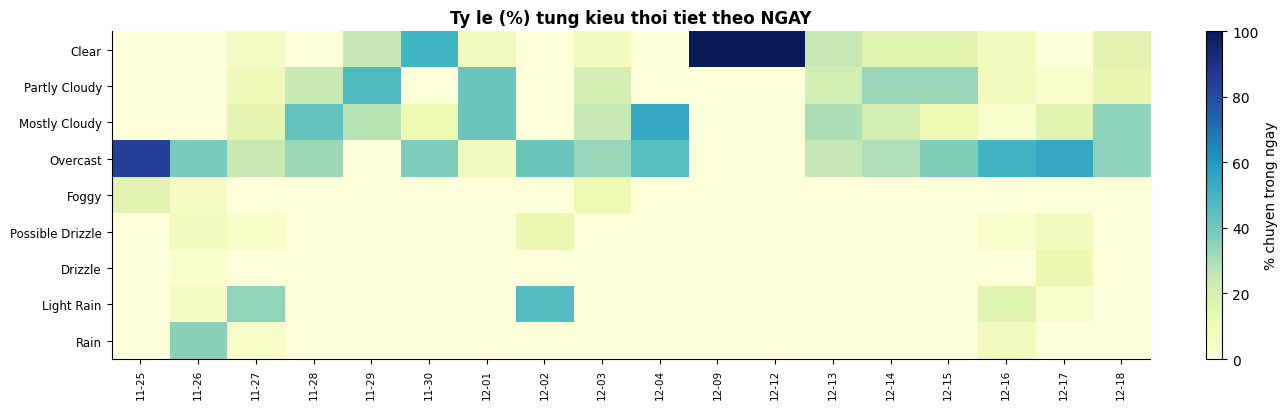

O trong = ngay do khong co kieu thoi tiet nay.
Cang nhieu o trong -> kieu thoi tiet do cang bi troi vao vai ngay cu the.


In [3]:
# Ban do: ngay nao co kieu thoi tiet nao
pv = (df.groupby(["_ngay","short_summary"]).size()
        .unstack(fill_value=0).reindex(columns=TT, fill_value=0))
pv = (pv.T / pv.sum(axis=1)).T * 100
fig, ax = plt.subplots(figsize=(13, 4.2))
im = ax.imshow(pv.T, cmap="YlGnBu", aspect="auto")
ax.set_xticks(range(len(pv))); ax.set_xticklabels(
    [str(d.date())[5:] for d in sorted(df.date_local.unique())], rotation=90, fontsize=7.5)
ax.set_yticks(range(len(TT))); ax.set_yticklabels(TT, fontsize=8.5)
ax.set_title("Ty le (%) tung kieu thoi tiet theo NGAY", fontweight="bold")
ax.grid(False); fig.colorbar(im, fraction=0.02).set_label("% chuyen trong ngay")
fig.tight_layout(); plt.show()
print("O trong = ngay do khong co kieu thoi tiet nay.")
print("Cang nhieu o trong -> kieu thoi tiet do cang bi troi vao vai ngay cu the.")

**2. 📊 Bóc tách phương sai — thời tiết thêm được bao nhiêu?**

Lần lượt cố định từng yếu tố, xem phổ giá thu hẹp thế nào.

In [4]:
print("Pho gia thu hep the nao khi lan luot co dinh tung yeu to?")
print()
for ten, dd in [("Uber", dfU), ("Lyft", dfL)]:
    b = pd.cut(dd.distance, BINS)
    tho = dd.groupby(b, observed=True).price.std().mean()
    xe  = dd.groupby([b, "name"], observed=True).price.std().mean()
    tt  = dd.groupby([b, "name", "short_summary"], observed=True).price.std().mean()
    lech = dd.groupby([b, "name", "short_summary"], observed=True).price.mean()              .groupby(level=[0, 1]).std().mean()
    print(f"  {ten}")
    print(f"     chi co dinh QUANG DUONG          : {tho:>5.2f} USD")
    print(f"     + co dinh LOAI XE                : {xe:>5.2f} USD   (giam {(1-xe/tho)*100:.0f}%)")
    print(f"     + co dinh THOI TIET              : {tt:>5.2f} USD   (giam them {(1-tt/xe)*100:.0f}%)")
    print(f"     lech GIUA cac kieu thoi tiet     : {lech:>5.2f} USD   (= {lech/tho*100:.1f}% pho gia tho)")
    print()
print("=> So sanh: KHU VUC giai thich 14-17% pho gia tho.")
print("   THOI TIET chi ~5% -> yeu hon khu vuc gan 3 lan.")

Pho gia thu hep the nao khi lan luot co dinh tung yeu to?

  Uber
     chi co dinh QUANG DUONG          :  9.78 USD
     + co dinh LOAI XE                :  2.39 USD   (giam 76%)
     + co dinh THOI TIET              :  2.19 USD   (giam them 8%)
     lech GIUA cac kieu thoi tiet     :  0.53 USD   (= 5.4% pho gia tho)

  Lyft
     chi co dinh QUANG DUONG          : 11.10 USD
     + co dinh LOAI XE                :  3.31 USD   (giam 70%)
     + co dinh THOI TIET              :  2.98 USD   (giam them 10%)
     lech GIUA cac kieu thoi tiet     :  0.52 USD   (= 4.7% pho gia tho)

=> So sanh: KHU VUC giai thich 14-17% pho gia tho.
   THOI TIET chi ~5% -> yeu hon khu vuc gan 3 lan.


**3. 🌈 Phổ giá theo thời tiết — tách riêng từng loại xe**

Mỗi hãng một hình, mỗi loại xe một ô. Trong từng ô, **mỗi kiểu thời tiết có phổ giá riêng**.

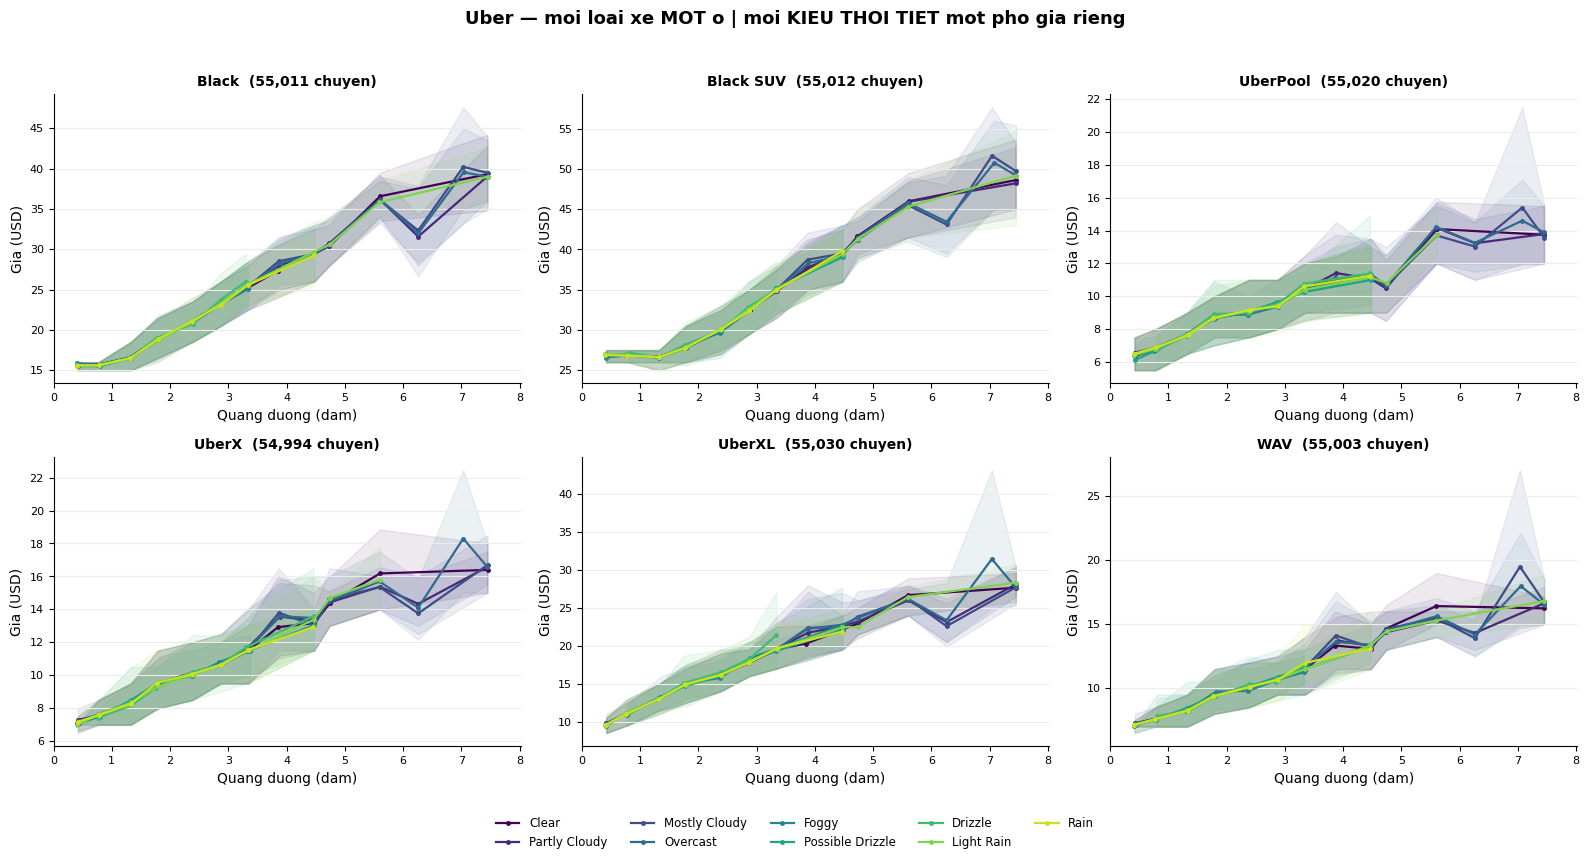

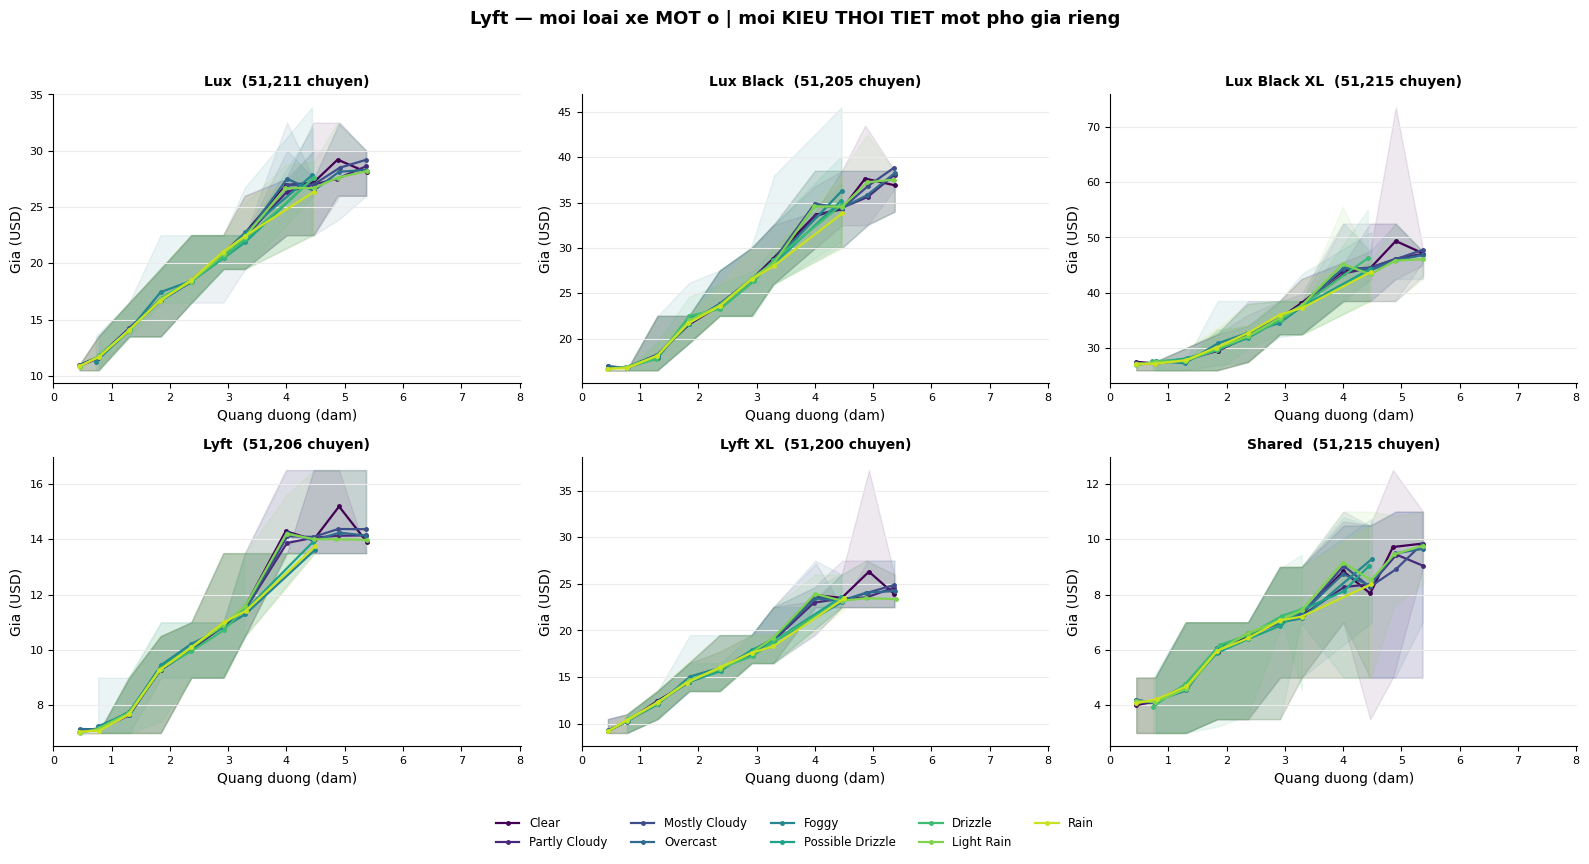

Cac dai mau chong khit len nhau -> thoi tiet gan nhu khong doi duoc gia.


In [5]:
def duong_gia(d, nmin=25):
    g = d.groupby(pd.cut(d.distance, BINS), observed=True).agg(
            x=("distance","mean"), y=("price","mean"),
            lo=("price", lambda v: v.quantile(.10)),
            hi=("price", lambda v: v.quantile(.90)),
            n=("price","size")).dropna()
    return g[g.n >= nmin]

def luoi_thoi_tiet(ten_hang, dd, nmin_tt=2000):
    dung = [t for t in TT if (dd.short_summary == t).sum() >= nmin_tt]
    svc = sorted(dd.name.unique())
    fig, axes = plt.subplots(2, 3, figsize=(16, 8.5))
    for ax, s_ in zip(axes.flat, svc):
        ds = dd[dd.name == s_]
        for t_ in dung:
            g = duong_gia(ds[ds.short_summary == t_])
            if not len(g):
                continue
            ax.fill_between(g.x, g.lo, g.hi, color=MAU_TT[t_], alpha=.09)
            ax.plot(g.x, g.y, color=MAU_TT[t_], lw=1.6, marker="o", ms=2.5, label=t_)
        ax.set_title(f"{s_}  ({len(ds):,} chuyen)", fontweight="bold", fontsize=10)
        ax.set_xlim(*XLIM)
        ax.set_xlabel("Quang duong (dam)"); ax.set_ylabel("Gia (USD)")
        ax.grid(axis="x", visible=False); ax.tick_params(labelsize=8)
    h, l = axes.flat[0].get_legend_handles_labels()
    fig.legend(h, l, loc="lower center", ncol=5, fontsize=8.5, frameon=False,
               bbox_to_anchor=(.5, -.02))
    fig.suptitle(f"{ten_hang} — moi loai xe MOT o | moi KIEU THOI TIET mot pho gia rieng",
                 fontweight="bold", fontsize=13)
    fig.tight_layout(rect=[0, .05, 1, .96]); plt.show()

luoi_thoi_tiet("Uber", dfU)
luoi_thoi_tiet("Lyft", dfL)
print("Cac dai mau chong khit len nhau -> thoi tiet gan nhu khong doi duoc gia.")

**4. 🏢 Giá trung bình theo thời tiết — Uber vs Lyft**

cab_type,Lyft,Uber,chenh_%,so_chuyen,q.duong_TB
short_summary,,,,,
Clear,17.316,15.721,-9.21,80188,2.19
Partly Cloudy,17.384,15.777,-9.25,117114,2.19
Mostly Cloudy,17.409,15.844,-8.99,134461,2.20
Overcast,17.323,15.799,-8.80,201239,2.19
Foggy,17.506,15.637,-10.68,8284,2.16
Possible Drizzle,17.237,15.806,-8.30,17150,2.19
Drizzle,17.344,15.781,-9.01,6718,2.18
Light Rain,17.335,15.845,-8.60,50422,2.19
Rain,17.312,15.835,-8.53,21746,2.18


!! Chu y cot q.duong_TB: neu khac nhau thi chenh lech gia co the do
   co cau chuyen di, khong phai do thoi tiet.


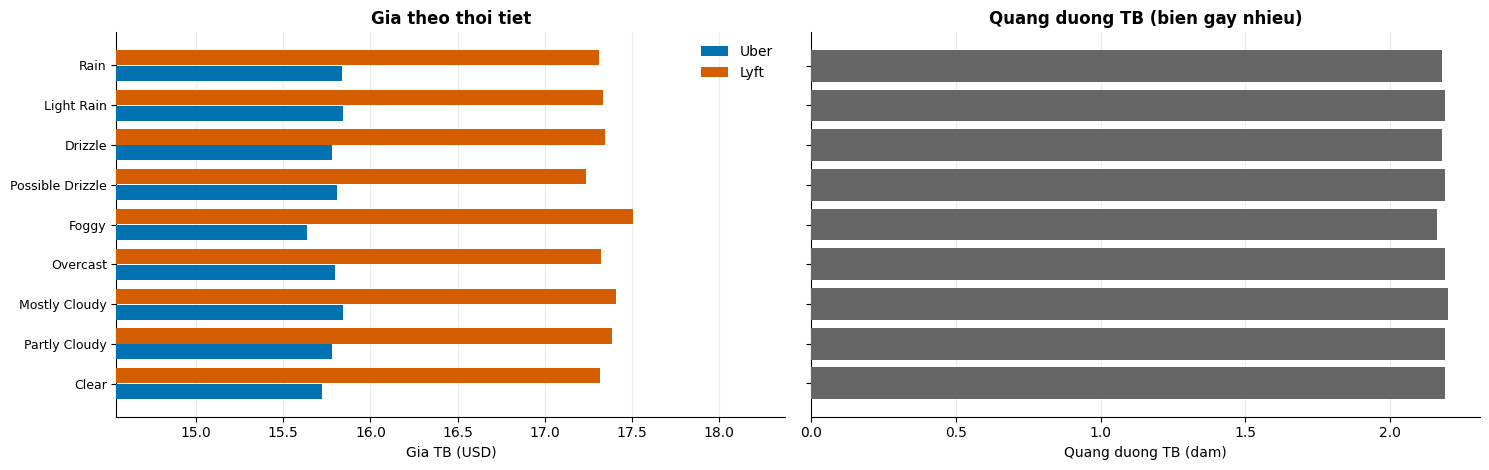

Uber: bien thien gia giua cac kieu thoi tiet = 1.33%
Lyft: bien thien gia giua cac kieu thoi tiet = 1.56%


In [6]:
cw = so_sanh_hang(df, "short_summary")
n_ = df.groupby("short_summary").size()
cw = cw.loc[[t for t in TT if n_.get(t, 0) >= 2000]]
cw["so_chuyen"] = n_.reindex(cw.index).values
cw["q.duong_TB"] = df.groupby("short_summary").distance.mean().reindex(cw.index).round(2).values
display(cw)
print("!! Chu y cot q.duong_TB: neu khac nhau thi chenh lech gia co the do")
print("   co cau chuyen di, khong phai do thoi tiet.")

fig, ax = plt.subplots(1, 2, figsize=(15, 4.8))
y = np.arange(len(cw))
ax[0].barh(y-0.2, cw["Uber"], height=.38, color=MAU_HANG["Uber"], label="Uber", zorder=3)
ax[0].barh(y+0.2, cw["Lyft"], height=.38, color=MAU_HANG["Lyft"], label="Lyft", zorder=3)
ax[0].set_yticks(y); ax[0].set_yticklabels(cw.index, fontsize=9)
ax[0].set_xlim(cw[["Uber","Lyft"]].min().min()*.93, None)
ax[0].set_xlabel("Gia TB (USD)"); ax[0].set_title("Gia theo thoi tiet", fontweight="bold")
ax[0].legend(frameon=False)

ax[1].barh(y, cw["q.duong_TB"], color=MUT, zorder=3)
ax[1].set_yticks(y); ax[1].set_yticklabels([])
ax[1].set_xlabel("Quang duong TB (dam)")
ax[1].set_title("Quang duong TB (bien gay nhieu)", fontweight="bold")
for a in ax: a.grid(axis="y", visible=False)
fig.tight_layout(); plt.show()

for ten, dd in [("Uber", dfU), ("Lyft", dfL)]:
    g = dd.groupby("short_summary").price.mean().reindex(cw.index)
    print(f"{ten}: bien thien gia giua cac kieu thoi tiet = {(g.max()/g.min()-1)*100:.2f}%")

**5. ☔ Thời tiết → HỆ SỐ NHÂN (chỉ Lyft)**

Thời tiết xấu thường được cho là làm tăng cầu → tăng surge. Kiểm chứng.

,so_chuyen,ty_le_surge_%,mult_TB
short_summary,,,
Clear,38641,7.11,1.032
Partly Cloudy,56630,6.85,1.031
Mostly Cloudy,64683,7.10,1.033
Overcast,97366,6.58,1.030
Foggy,4002,7.85,1.034
Possible Drizzle,8068,6.80,1.030
Drizzle,3109,6.27,1.028
Light Rain,24313,6.58,1.031
Rain,10440,6.61,1.029


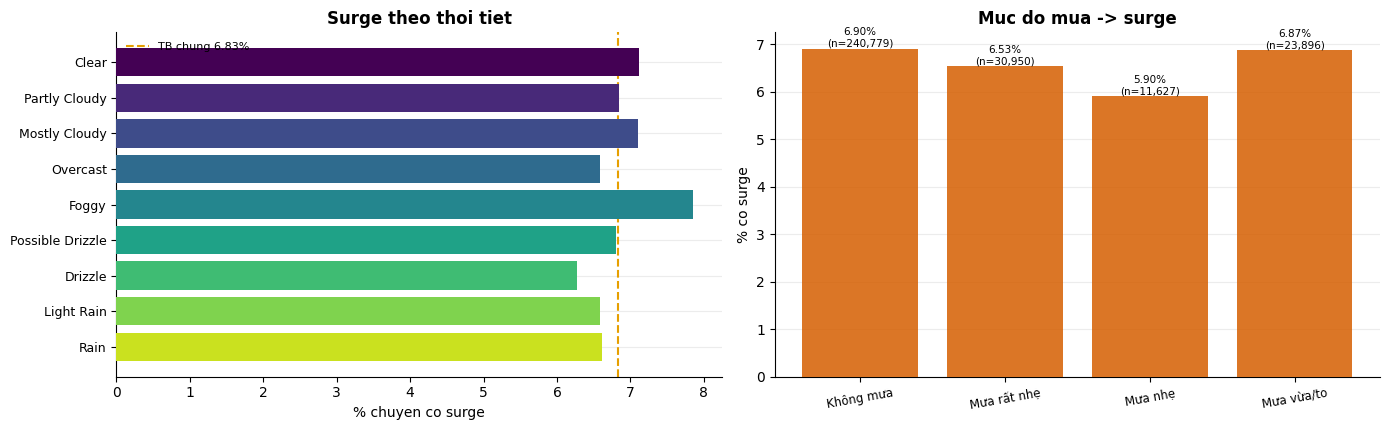

Bien do surge giua cac kieu thoi tiet: 6.27% -> 7.85% (1.25 lan)
eta(thoi tiet -> surge) = 0.0104
So sanh: eta(khu vuc -> surge) = 0.1346


In [7]:
w = dfL.groupby("short_summary").agg(
        so_chuyen=("price","size"), ty_le_surge=("is_surge","mean"),
        mult_TB=("surge_multiplier","mean"))
w = w[w.so_chuyen >= 2000].reindex([t for t in TT if t in w.index])
w["ty_le_surge_%"] = (w.ty_le_surge*100).round(2)
display(w[["so_chuyen","ty_le_surge_%","mult_TB"]].round(3))

fig, ax = plt.subplots(1, 2, figsize=(14, 4.4))
ax[0].barh(range(len(w)), w["ty_le_surge_%"].values[::-1],
           color=[MAU_TT[t] for t in w.index[::-1]], zorder=3)
ax[0].set_yticks(range(len(w))); ax[0].set_yticklabels(w.index[::-1], fontsize=9)
ax[0].axvline(dfL.is_surge.mean()*100, color=ORANGE, ls="--", lw=1.5,
              label=f"TB chung {dfL.is_surge.mean()*100:.2f}%")
ax[0].set_xlabel("% chuyen co surge"); ax[0].set_title("Surge theo thoi tiet", fontweight="bold")
ax[0].legend(fontsize=8, frameon=False)

dfL["nhom_mua"] = pd.cut(dfL.precipIntensity, [-1e-9, 1e-4, .01, .05, 10],
                          labels=["Không mưa","Mưa rất nhẹ","Mưa nhẹ","Mưa vừa/to"])
g = dfL.groupby("nhom_mua", observed=True).agg(surge=("is_surge","mean"), n=("price","size"))
ax[1].bar(range(len(g)), g.surge*100, color=RED, alpha=.85, zorder=3)
ax[1].set_xticks(range(len(g))); ax[1].set_xticklabels(g.index, fontsize=8.5, rotation=10)
for i, (v, n2) in enumerate(zip(g.surge*100, g.n)):
    ax[1].text(i, v, f"{v:.2f}%\n(n={n2:,})", ha="center", va="bottom", fontsize=7.5)
ax[1].set_ylabel("% co surge"); ax[1].set_title("Muc do mua -> surge", fontweight="bold")
for a in ax: a.grid(axis="x", visible=False)
fig.tight_layout(); plt.show()

print(f"Bien do surge giua cac kieu thoi tiet: "
      f"{w['ty_le_surge_%'].min():.2f}% -> {w['ty_le_surge_%'].max():.2f}% "
      f"({w['ty_le_surge_%'].max()/w['ty_le_surge_%'].min():.2f} lan)")
print(f"eta(thoi tiet -> surge) = {eta(dfL.short_summary, dfL.is_surge):.4f}")
print(f"So sanh: eta(khu vuc -> surge) = {eta(dfL.source, dfL.is_surge):.4f}")

**6. 📈 Các biến thời tiết liên tục**

In [8]:
WCOLS = ["temperature","apparentTemperature","precipIntensity","precipProbability",
         "humidity","windSpeed","visibility","cloudCover","dewPoint"]
rows = []
for c in WCOLS:
    rows.append({"biến": c,
        "r_giá_Uber":  round(np.corrcoef(dfU[c], dfU.price)[0,1], 4),
        "r_giá_Lyft":  round(np.corrcoef(dfL[c], dfL.price)[0,1], 4),
        "eta_surge":   round(eta(binned(dfL[c]), dfL.is_surge), 4),
        "r_với_ngày":  round(abs(np.corrcoef(df._ngay, df[c])[0,1]), 3)})
t = pd.DataFrame(rows).sort_values("eta_surge", ascending=False).reset_index(drop=True)
display(t)
print("|r| < 0.05  -> coi nhu khong co quan he.")
print("r_với_ngày cao -> bien do bi lan voi hieu ung ngay, khong dang tin.")

,biến,r_giá_Uber,r_giá_Lyft,eta_surge,r_với_ngày
0,cloudCover,0.0021,-0.0002,0.0124,0.080
1,humidity,-0.0009,-0.0013,0.0120,0.161
2,dewPoint,0.0007,-0.0019,0.0118,0.266
3,apparentTemperature,0.0005,-0.0015,0.0097,0.232
4,visibility,0.0004,0.0022,0.0087,0.152
5,temperature,0.0016,-0.0020,0.0086,0.255
6,windSpeed,0.0043,-0.0014,0.0079,0.068
7,precipProbability,0.0016,-0.0015,0.0067,0.145
8,precipIntensity,0.0017,-0.0010,0.0053,0.181


|r| < 0.05  -> coi nhu khong co quan he.
r_với_ngày cao -> bien do bi lan voi hieu ung ngay, khong dang tin.


**7. 📌 Kết luận**

In [9]:
b = pd.cut(dfU.distance, BINS)
tho_u = dfU.groupby(b, observed=True).price.std().mean()
lech_u = dfU.groupby([b, "name", "short_summary"], observed=True).price.mean()             .groupby(level=[0, 1]).std().mean()

print("="*68); print("THOI TIET — KET LUAN"); print("="*68)
print(f"1) Voi GIA: hieu ung RAT YEU")
print(f"   - Lech giua cac kieu thoi tiet chi {lech_u:.2f} USD = {lech_u/tho_u*100:.1f}% pho gia tho")
print(f"   - So sanh: khu vuc 14-17%, loai xe 70-76%")
print(f"   - eta(thoi tiet -> gia): Uber {eta(dfU.short_summary, dfU.price):.4f} | "
      f"Lyft {eta(dfL.short_summary, dfL.price):.4f}")
print()
print(f"2) Voi SURGE: cung yeu")
print(f"   - eta(thoi tiet -> surge) = {eta(dfL.short_summary, dfL.is_surge):.4f}")
print(f"   - eta(khu vuc  -> surge) = {eta(dfL.source, dfL.is_surge):.4f}  <- manh hon nhieu")
print()
print("3) HAN CHE NGHIEM TRONG:")
hiem = df.groupby("short_summary")._ngay.nunique()
for k in hiem[hiem <= 5].index:
    print(f"   - '{k}' chi xuat hien {hiem[k]} ngay -> lan voi hieu ung ngay")
print("   - Chi 18 ngay mua dong Boston, khong co thoi tiet cuc doan (bao, tuyet lon)")
print()
print("4) KHUYEN NGHI:")
print("   - KHONG dua thoi tiet vao model GIA (dong gop ~0)")
print("   - Co the giu short_summary cho model SURGE de theo doi, nhung ky vong thap")
print("   - Tren du lieu GreenSM (khi hau VN, mua mua ro ret) co the khac han -> danh gia lai")

THOI TIET — KET LUAN
1) Voi GIA: hieu ung RAT YEU
   - Lech giua cac kieu thoi tiet chi 0.53 USD = 5.4% pho gia tho
   - So sanh: khu vuc 14-17%, loai xe 70-76%
   - eta(thoi tiet -> gia): Uber 0.0050 | Lyft 0.0045

2) Voi SURGE: cung yeu
   - eta(thoi tiet -> surge) = 0.0104
   - eta(khu vuc  -> surge) = 0.1346  <- manh hon nhieu

3) HAN CHE NGHIEM TRONG:
   - 'Drizzle' chi xuat hien 2 ngay -> lan voi hieu ung ngay
   - 'Foggy' chi xuat hien 3 ngay -> lan voi hieu ung ngay
   - 'Light Rain' chi xuat hien 5 ngay -> lan voi hieu ung ngay
   - 'Possible Drizzle' chi xuat hien 5 ngay -> lan voi hieu ung ngay
   - 'Rain' chi xuat hien 3 ngay -> lan voi hieu ung ngay
   - Chi 18 ngay mua dong Boston, khong co thoi tiet cuc doan (bao, tuyet lon)

4) KHUYEN NGHI:
   - KHONG dua thoi tiet vao model GIA (dong gop ~0)
   - Co the giu short_summary cho model SURGE de theo doi, nhung ky vong thap
   - Tren du lieu GreenSM (khi hau VN, mua mua ro ret) co the khac han -> danh gia lai
